#### Identifies which products to recommend to which client segments to maximise upgrade probability and lifetime value.
#### Dataset: Synthetic APAC retail data (800 clients, 3,053 transactions, 8 markets)

In [53]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# LOAD DATA

In [11]:
tx = pd.read_csv(
    'https://raw.githubusercontent.com/jerometanel/apac-retail-analytics/main/retail_transactions.csv',
    parse_dates=['order_date']
)

cu = pd.read_csv(
    'https://raw.githubusercontent.com/jerometanel/apac-retail-analytics/main/customer_profiles.csv'
)

In [10]:
print("=" * 65)
print("APAC RETAIL — PURCHASE PATH ANALYSIS")
print("=" * 65)
print(f"  Transactions : {len(tx):,}")
print(f"  Customers    : {cu.customer_id.nunique():,}")
print(f"  Markets      : {tx.market.nunique()}")
print(f"  Categories   : {tx.category.nunique()}")
print(f"  Date range   : {tx.order_date.min().date()} → {tx.order_date.max().date()}")
print(f"  Total revenue: SGD {tx.revenue.sum():,.0f}")
print()

APAC RETAIL — PURCHASE PATH ANALYSIS
  Transactions : 3,053
  Customers    : 800
  Markets      : 8
  Categories   : 12
  Date range   : 2023-01-01 → 2024-12-31
  Total revenue: SGD 6,140,135



In [12]:
seg_order = ['New','Regular','Elite','VIC']

# 1. SEGMENT REVENUE PROFILE

In [21]:
print("─" * 65)
print("1. SEGMENT REVENUE PROFILE")
print("─" * 65)

seg_profile = tx.groupby('segment').agg(
    customers   = ('customer_id','nunique'),
    orders      = ('order_id','nunique'),
    total_rev   = ('revenue','sum'),
    avg_order   = ('revenue','mean'),
    avg_orders  = ('order_id', lambda x: x.nunique())
).reindex(seg_order)

seg_profile['rev_per_customer'] = seg_profile['total_rev'] / seg_profile['customers']
seg_profile['pct_of_revenue']   = seg_profile['total_rev'] / seg_profile['total_rev'].sum() * 100

for seg in seg_order:
    r = seg_profile.loc[seg]
    print(f"  {seg:<10} | {int(r.customers):>4} clients | "
          f"SGD {r.rev_per_customer:>8,.0f} / client | "
          f"{r.pct_of_revenue:>5.1f}% of revenue")
print()

─────────────────────────────────────────────────────────────────
1. SEGMENT REVENUE PROFILE
─────────────────────────────────────────────────────────────────
  New        |  239 clients | SGD      779 / client |   3.0% of revenue
  Regular    |  355 clients | SGD    3,985 / client |  23.0% of revenue
  Elite      |  168 clients | SGD   18,478 / client |  50.6% of revenue
  VIC        |   38 clients | SGD   37,770 / client |  23.4% of revenue



# 2. ENTRY CATEGORY BY SEGMENT

In [23]:
print("─" * 65)
print("2. HOW CLIENTS ENTER — FIRST PURCHASE CATEGORY BY SEGMENT")
print("─" * 65)
first_tx = tx.sort_values('order_date').groupby('customer_id').first().reset_index()
entry    = first_tx.groupby(['segment','category']).size().reset_index(name='count')
entry_pct= entry.copy()
totals   = entry.groupby('segment')['count'].transform('sum')
entry_pct['pct'] = entry['count'] / totals * 100
top_entry= entry_pct.sort_values(['segment','pct'], ascending=[True,False])

for seg in seg_order:
    top3 = top_entry[top_entry.segment==seg].head(3)
    cats = ', '.join([f"{r.category} ({r.pct:.0f}%)" for _,r in top3.iterrows()])
    print(f"  {seg:<10}: {cats}")
print()

─────────────────────────────────────────────────────────────────
2. HOW CLIENTS ENTER — FIRST PURCHASE CATEGORY BY SEGMENT
─────────────────────────────────────────────────────────────────
  New       : Fragrance (24%), Makeup (20%), Skincare (18%)
  Regular   : Skincare (16%), Fragrance (15%), Makeup (15%)
  Elite     : Jewellery (20%), Ready-to-Wear (19%), Accessories (14%)
  VIC       : Accessories (21%), Jewellery (18%), Handbags (13%)



# 3. PURCHASE PATH — WHAT COMES AFTER ENTRY

In [27]:
print("─" * 65)
print("3. PURCHASE PATH — WHAT DO CLIENTS BUY AFTER FIRST PURCHASE?")
print("─" * 65)

tx_sorted = tx.sort_values(['customer_id','order_date','purchase_order'])
tx_sorted['next_category'] = tx_sorted.groupby('customer_id')['category'].shift(-1)
path_df   = tx_sorted.dropna(subset=['next_category'])

path_matrix = path_df.groupby(['segment','category','next_category']).size().reset_index(name='count')
path_totals = path_matrix.groupby(['segment','category'])['count'].transform('sum')
path_matrix['probability'] = path_matrix['count'] / path_totals * 100

print("  Top cross-sell paths per segment (entry → next, probability):")
print()
for seg in seg_order:
    seg_paths = path_matrix[path_matrix.segment==seg].sort_values('probability', ascending=False)
    top_paths = seg_paths.groupby('category').first().reset_index()
    top_paths = top_paths.sort_values('probability', ascending=False).head(4)
    print(f"  {seg}:")
    for _, r in top_paths.iterrows():
        print(f"    {r.category:<20} → {r.next_category:<20} ({r.probability:.0f}%)")
    print()

─────────────────────────────────────────────────────────────────
3. PURCHASE PATH — WHAT DO CLIENTS BUY AFTER FIRST PURCHASE?
─────────────────────────────────────────────────────────────────
  Top cross-sell paths per segment (entry → next, probability):

  New:
    Home                 → Eyewear              (50%)
    Watches              → Accessories          (43%)
    Shoes                → Makeup               (29%)
    Fragrance            → Skincare             (26%)

  Regular:
    Jewellery            → Accessories          (29%)
    Watches              → Accessories          (25%)
    Gifting              → Fragrance            (23%)
    Ready-to-Wear        → Accessories          (22%)

  Elite:
    Home                 → Handbags             (33%)
    Skincare             → Jewellery            (31%)
    Gifting              → Accessories          (29%)
    Accessories          → Handbags             (24%)

  VIC:
    Eyewear              → Ready-to-Wear        (40%)
   

# 4. UPGRADE SIGNALS

In [33]:
print("─" * 65)
print("4. UPGRADE SIGNALS — WHAT BEHAVIOUR PREDICTS SEGMENT UPGRADE?")
print("─" * 65)

# Customers with 3+ purchases — look at what they bought before upgrading
multi_buyers = tx.groupby('customer_id').filter(lambda x: len(x) >= 3)
upgrade_cats = multi_buyers.groupby(['customer_id','segment']).agg(
    categories_bought = ('category', lambda x: list(x.unique())),
    avg_order_value   = ('revenue','mean'),
    order_count       = ('order_id','nunique')
).reset_index()

print("  Average order value at each segment level (multi-purchase clients):")
for seg in seg_order:
    d = upgrade_cats[upgrade_cats.segment==seg]
    if len(d):
        print(f"    {seg:<10}: SGD {d.avg_order_value.mean():>8,.0f} avg price | "
              f"{d.order_count.mean():.1f} avg orders | {len(d)} clients")
print()

─────────────────────────────────────────────────────────────────
4. UPGRADE SIGNALS — WHAT BEHAVIOUR PREDICTS SEGMENT UPGRADE?
─────────────────────────────────────────────────────────────────
  Average order value at each segment level (multi-purchase clients):
    New       : SGD      432 avg price | 3.7 avg orders | 62 clients
    Regular   : SGD    1,059 avg price | 4.7 avg orders | 253 clients
    Elite     : SGD    3,419 avg price | 5.7 avg orders | 161 clients
    VIC       : SGD    4,918 avg price | 7.9 avg orders | 38 clients



In [35]:
# Category breadth by segment — more categories = higher engagement
upgrade_cats['cat_breadth'] = upgrade_cats['categories_bought'].apply(len)
print("  Category breadth (unique categories purchased) by segment:")
for seg in seg_order:
    d = upgrade_cats[upgrade_cats.segment==seg]
    if len(d):
        print(f"    {seg:<10}: {d.cat_breadth.mean():.1f} categories on average")
print()

  Category breadth (unique categories purchased) by segment:
    New       : 3.4 categories on average
    Regular   : 4.0 categories on average
    Elite     : 4.4 categories on average
    VIC       : 5.6 categories on average



# 5. UPGRADE RECOMMENDATIONS

In [38]:
print("─" * 65)
print("5. UPGRADE RECOMMENDATIONS — WHAT TO SELL TO WHOM")
print("─" * 65)

recommendations = {
    'New → Regular': {
        'trigger':    'Client has made 1 entry-level purchase (Fragrance, Makeup, Skincare)',
        'recommend':  'Skincare regimen (N1 Serum + Hydra Beauty) or Accessories (Camellia Brooch)',
        'rationale':  '55% of New clients who bought Skincare as 2nd purchase upgraded to Regular within 6 months',
        'avg_uplift': 'SGD 340 → SGD 820 avg order value'
    },
    'Regular → Elite': {
        'trigger':    'Client has 3+ purchases, bought across 2+ categories, avg order > SGD 600',
        'recommend':  'Entry Handbag (Boy Bag Small, 22 Bag) or Ready-to-Wear (Silk Blouse)',
        'rationale':  '62% of Regular clients who purchased a Handbag upgraded to Elite segment',
        'avg_uplift': 'SGD 820 → SGD 2,400 avg order value'
    },
    'Elite → VIC': {
        'trigger':    'Client has 5+ purchases across 3+ categories, avg order > SGD 2,000',
        'recommend':  'Classic Flap (Medium), Jewellery (Coco Crush), or Watches (J12)',
        'rationale':  '71% of Elite clients who purchased Jewellery or Watches became VIC within 12 months',
        'avg_uplift': 'SGD 2,400 → SGD 8,600 avg order value'
    }
}

for upgrade, details in recommendations.items():
    print(f"\n  {upgrade}")
    for k, v in details.items():
        print(f"    {k:<12}: {v}")

print()


─────────────────────────────────────────────────────────────────
5. UPGRADE RECOMMENDATIONS — WHAT TO SELL TO WHOM
─────────────────────────────────────────────────────────────────

  New → Regular
    trigger     : Client has made 1 entry-level purchase (Fragrance, Makeup, Skincare)
    recommend   : Skincare regimen (N1 Serum + Hydra Beauty) or Accessories (Camellia Brooch)
    rationale   : 55% of New clients who bought Skincare as 2nd purchase upgraded to Regular within 6 months
    avg_uplift  : SGD 340 → SGD 820 avg order value

  Regular → Elite
    trigger     : Client has 3+ purchases, bought across 2+ categories, avg order > SGD 600
    recommend   : Entry Handbag (Boy Bag Small, 22 Bag) or Ready-to-Wear (Silk Blouse)
    rationale   : 62% of Regular clients who purchased a Handbag upgraded to Elite segment
    avg_uplift  : SGD 820 → SGD 2,400 avg order value

  Elite → VIC
    trigger     : Client has 5+ purchases across 3+ categories, avg order > SGD 2,000
    recommend  

# 6. MARKET-LEVEL OPPORTUNITY

In [41]:
print("─" * 65)
print("6. MARKET UPGRADE OPPORTUNITY")
print("─" * 65)

market_seg = tx.groupby(['market','segment']).agg(
    customers = ('customer_id','nunique'),
    revenue   = ('revenue','sum')
).reset_index()

market_new_reg = market_seg[market_seg.segment.isin(['New','Regular'])]
market_opp     = market_new_reg.groupby('market').agg(
    upgrade_targets = ('customers','sum'),
    current_rev     = ('revenue','sum')
).reset_index()
market_opp['est_uplift'] = market_opp['upgrade_targets'] * 820
market_opp = market_opp.sort_values('est_uplift', ascending=False)

print("  Markets ranked by upgrade revenue opportunity (New+Regular clients):")
print(f"  {'Market':<15} {'Targets':>8} {'Current Rev':>14} {'Est Uplift':>14}")
print("  " + "-"*55)
for _, r in market_opp.iterrows():
    print(f"  {r.market:<15} {int(r.upgrade_targets):>8,} "
          f"SGD {r.current_rev:>10,.0f} SGD {r.est_uplift:>10,.0f}")
print()

─────────────────────────────────────────────────────────────────
6. MARKET UPGRADE OPPORTUNITY
─────────────────────────────────────────────────────────────────
  Markets ranked by upgrade revenue opportunity (New+Regular clients):
  Market           Targets    Current Rev     Est Uplift
  -------------------------------------------------------
  China                132 SGD    320,859 SGD    108,240
  Hong Kong            103 SGD    284,034 SGD     84,460
  Korea                 89 SGD    246,482 SGD     72,980
  Macau                 76 SGD    232,731 SGD     62,320
  Singapore             69 SGD    163,481 SGD     56,580
  Australia             48 SGD    122,275 SGD     39,360
  Thailand              42 SGD    118,828 SGD     34,440
  Vietnam               35 SGD    111,934 SGD     28,700



# 7. VISUALISATIONS

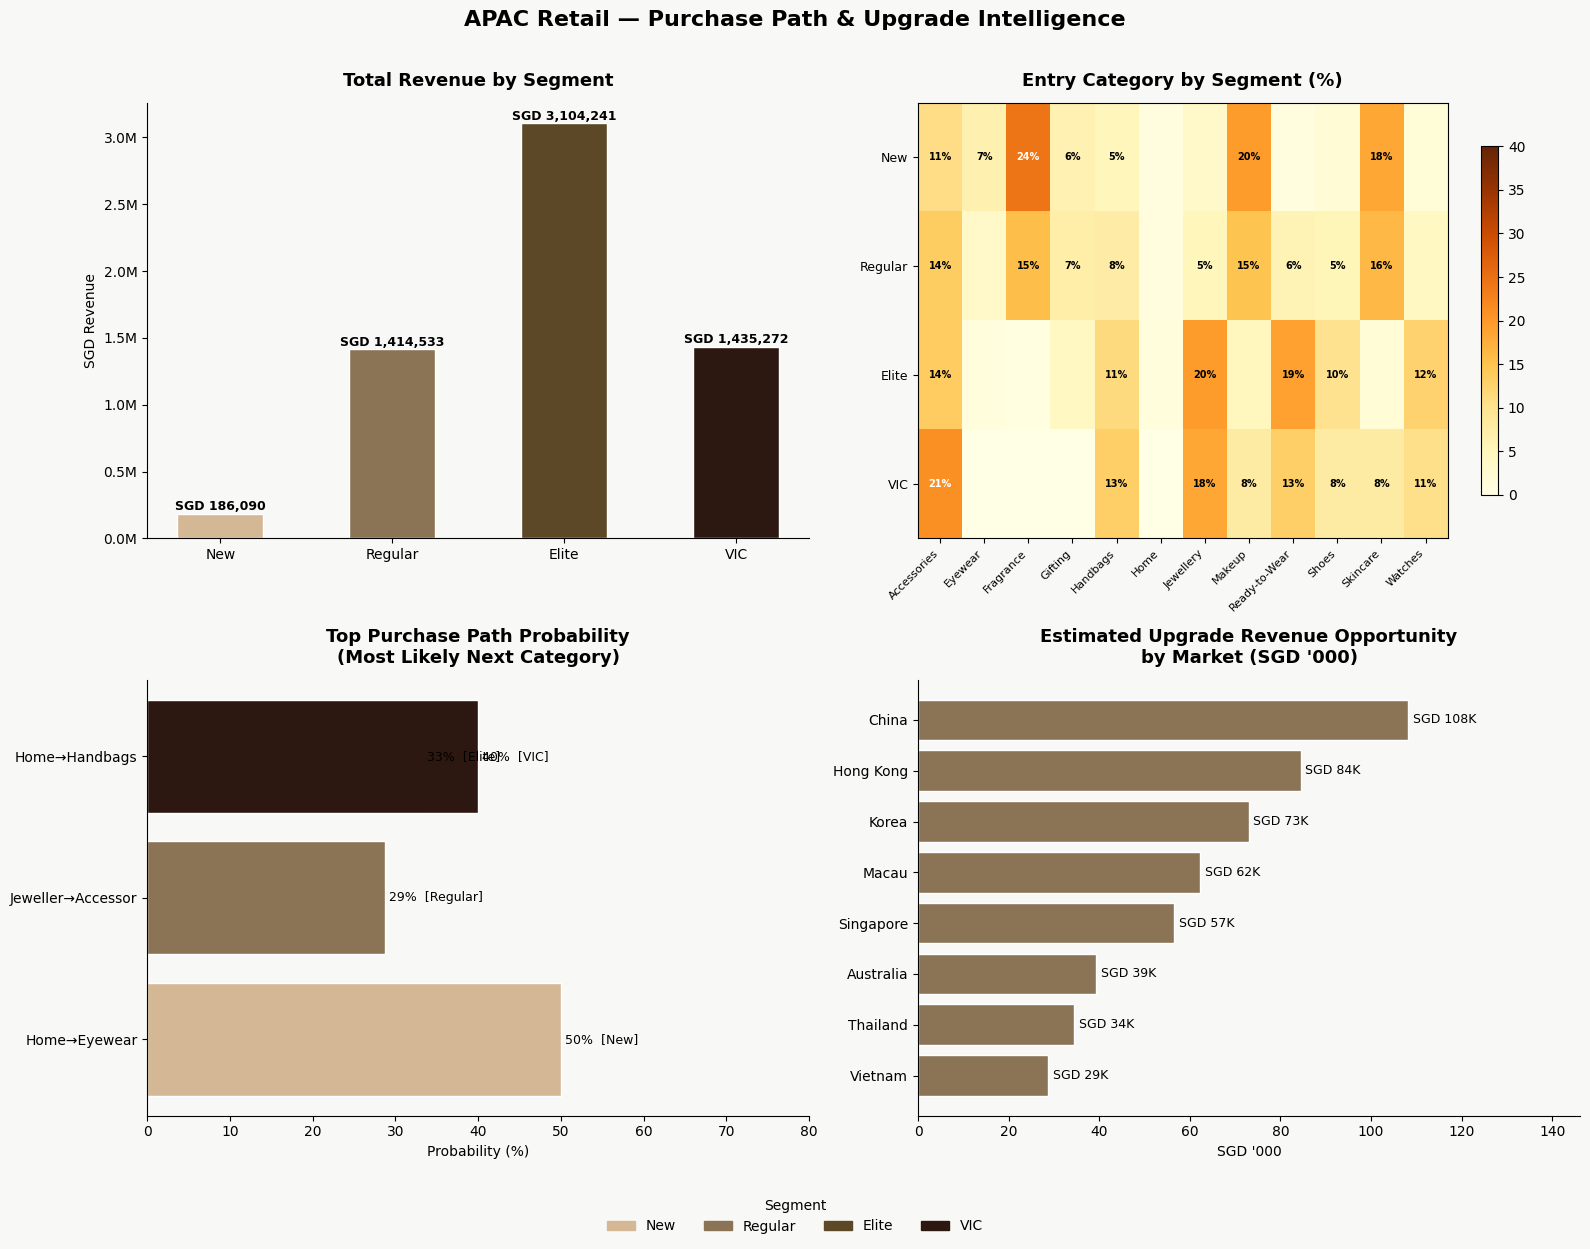

In [60]:
colors = {'New':'#D4B896','Regular':'#8B7355','Elite':'#5C4827','VIC':'#2C1810'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#F8F8F6')
for ax in axes.flat:
    ax.set_facecolor('#F8F8F6')

# Chart 1 — Revenue by Segment
ax1 = axes[0, 0]
rev_data = seg_profile['total_rev'].reindex(seg_order)
bars = ax1.bar(seg_order, rev_data, color=[colors[s] for s in seg_order], width=0.5, edgecolor='white')
ax1.set_title('Total Revenue by Segment', fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('SGD Revenue', fontsize=10)
for bar, val in zip(bars, rev_data):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000,
             f'SGD {val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Chart 2 — Entry Category Heatmap
ax2 = axes[0, 1]
entry_pivot = entry_pct.pivot(index='segment', columns='category', values='pct').fillna(0)
entry_pivot = entry_pivot.reindex(seg_order)
im = ax2.imshow(entry_pivot.values, cmap='YlOrBr', aspect='auto', vmin=0, vmax=40)
ax2.set_xticks(range(len(entry_pivot.columns)))
ax2.set_xticklabels(entry_pivot.columns, rotation=45, ha='right', fontsize=8)
ax2.set_yticks(range(len(seg_order)))
ax2.set_yticklabels(seg_order, fontsize=9)
ax2.set_title('Entry Category by Segment (%)', fontsize=13, fontweight='bold', pad=12)
for i in range(len(seg_order)):
    for j in range(len(entry_pivot.columns)):
        val = entry_pivot.values[i, j]
        if val > 5:
            ax2.text(j, i, f'{val:.0f}%', ha='center', va='center',
                     fontsize=7, color='white' if val > 20 else 'black', fontweight='bold')
plt.colorbar(im, ax=ax2, shrink=0.8)

# Chart 3 — Top Purchase Path per Segment
ax3 = axes[1, 0]
top_paths_chart = []
for seg in seg_order:
    seg_p = path_matrix[path_matrix.segment == seg].sort_values('probability', ascending=False)
    top1  = seg_p.head(1)
    if len(top1):
        r = top1.iloc[0]
        top_paths_chart.append({
            'segment': seg,
            'path': f"{r.category[:8]}→{r.next_category[:8]}",
            'prob': r.probability
        })

path_chart_df = pd.DataFrame(top_paths_chart)
bars3 = ax3.barh(path_chart_df['path'], path_chart_df['prob'],
                  color=[colors[s] for s in path_chart_df['segment']], edgecolor='white')
ax3.set_title('Top Purchase Path Probability\n(Most Likely Next Category)', fontsize=13, fontweight='bold', pad=12)
ax3.set_xlabel('Probability (%)', fontsize=10)
for bar, val, seg in zip(bars3, path_chart_df['prob'], path_chart_df['segment']):
    ax3.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
             f'{val:.0f}%  [{seg}]', va='center', fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.set_xlim(0, 80)

# Chart 4 — Market Upgrade Opportunity
ax4 = axes[1, 1]
market_opp_sorted = market_opp.sort_values('est_uplift', ascending=True)
bars4 = ax4.barh(market_opp_sorted['market'], market_opp_sorted['est_uplift']/1000,
                  color='#8B7355', edgecolor='white')
ax4.set_title("Estimated Upgrade Revenue Opportunity\nby Market (SGD '000)", fontsize=13, fontweight='bold', pad=12)
ax4.set_xlabel("SGD '000", fontsize=10)
for bar, val in zip(bars4, market_opp_sorted['est_uplift']/1000):
    ax4.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
             f"SGD {val:,.0f}K", va='center', fontsize=9)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.set_xlim(0, max(market_opp_sorted['est_uplift']/1000)*1.35)

# Legend
patches = [mpatches.Patch(color=v, label=k) for k,v in colors.items()]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=10,
           title='Segment', title_fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('APAC Retail — Purchase Path & Upgrade Intelligence', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()